In [1]:
from simulation_functions import *
from utils_analysis_for_simulation import *

from tqdm.notebook import tqdm

import numpy as np
import random as rnd

from copy import deepcopy

import matplotlib.pyplot as plt

c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Utente\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


## Config

In [2]:
APPLY_DROPRULE=False
DROP_RULES=[]

REPETITIONS_PER_EXPERIMENT=1000
TURNS=250

METRIC_WINDOW=200

In [3]:
RESULTS=load_results(['RK2v3','RK2v4'])

RK2v3
RK2v4
Number of valid entries: 431


## Plot styles

In [4]:
plt.style.use("seaborn-whitegrid")
import matplotlib as mpl

mpl.rcParams.update({
    # Font
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    
    # Axes and grid
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Lines and markers
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Default colormap for images
    "image.cmap": "Blues",

    # Default color cycle for plots
    "axes.prop_cycle": plt.cycler(
        color=[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
        ]
    ),

    # Figure
#     "figure.figsize": (6, 4),
#     "figure.dpi": 150,

    # Legend
    "legend.frameon": False,
})

mpl.rcParams["patch.force_edgecolor"] = True

# Topic-wise corner runs

In [5]:
import warnings
warnings.filterwarnings('ignore')

Running simulation for topic Overall...


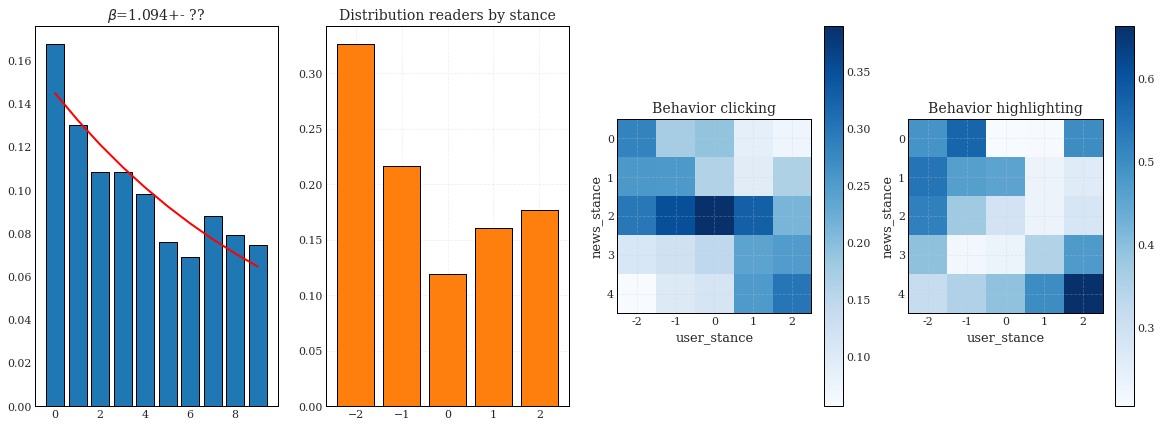

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

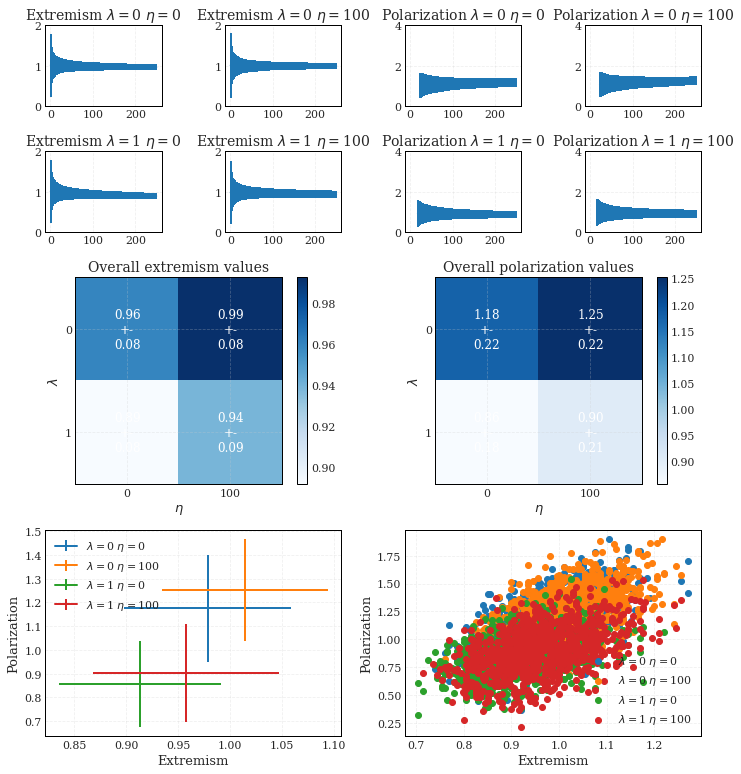

Running simulation for topic gender...


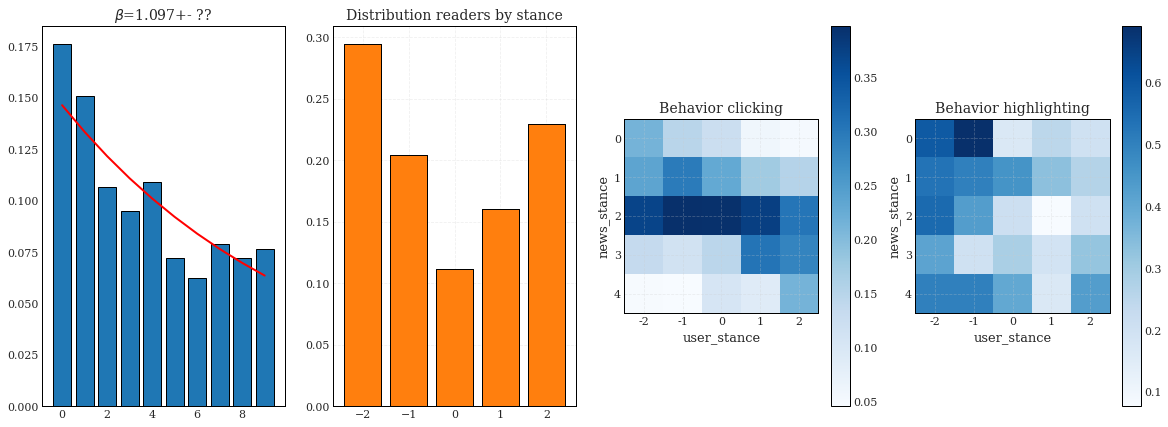

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

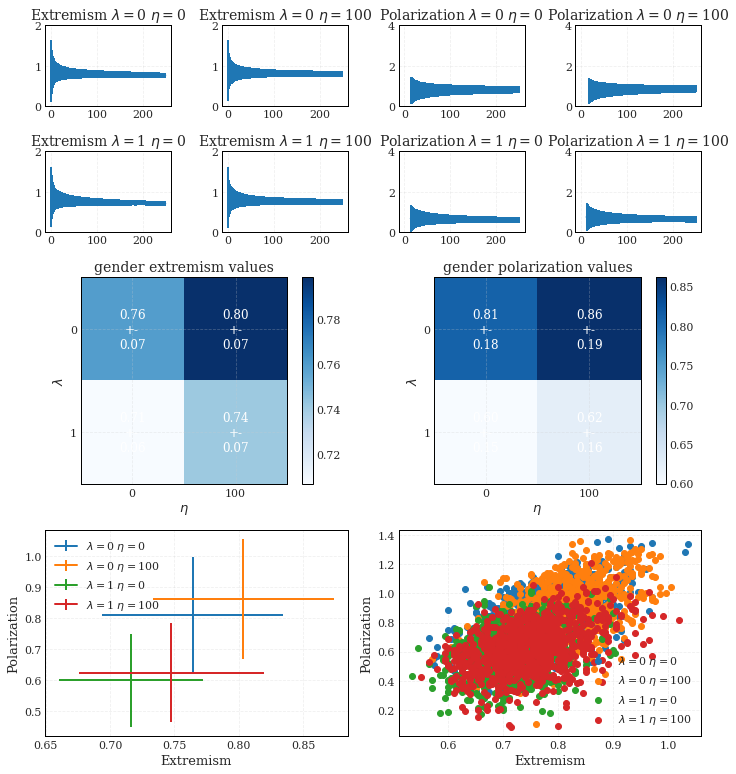

Running simulation for topic vaccines...


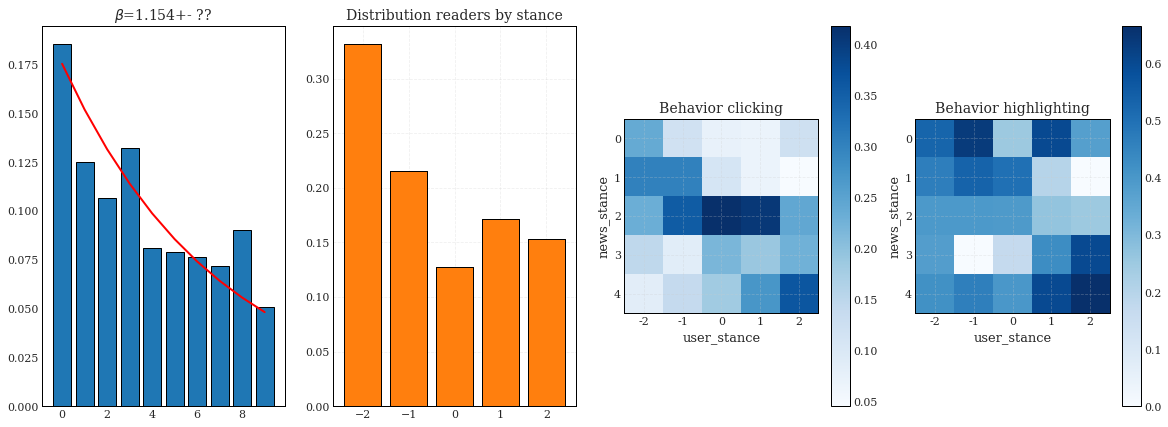

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

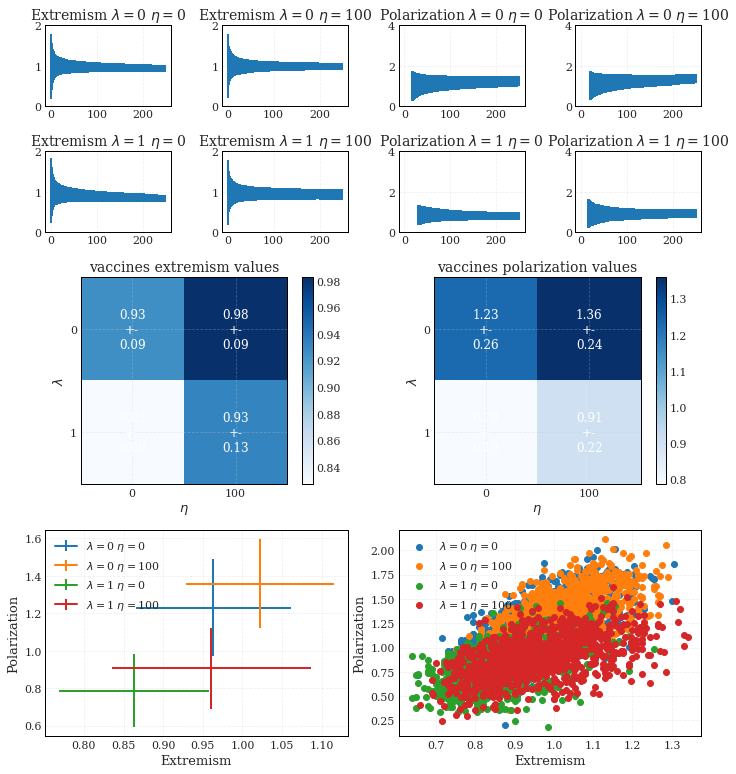

Running simulation for topic immigration...


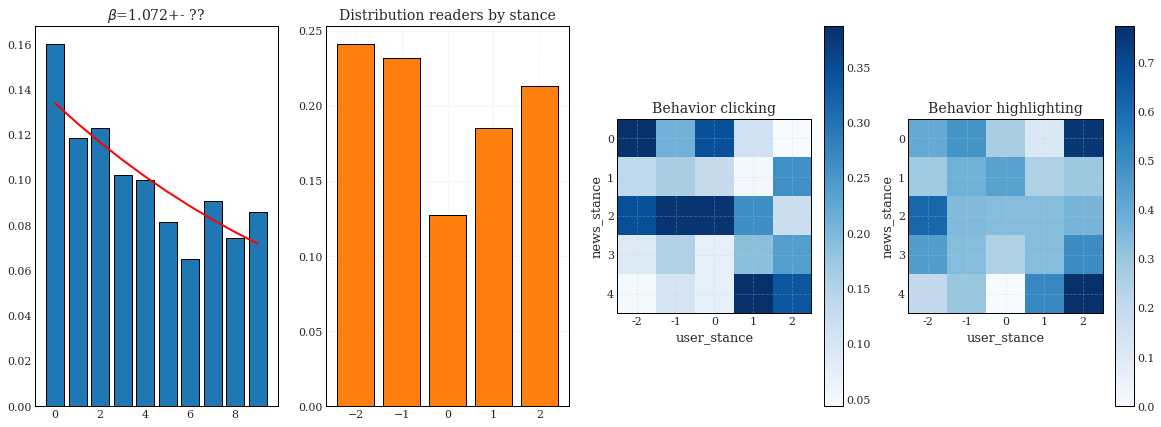

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

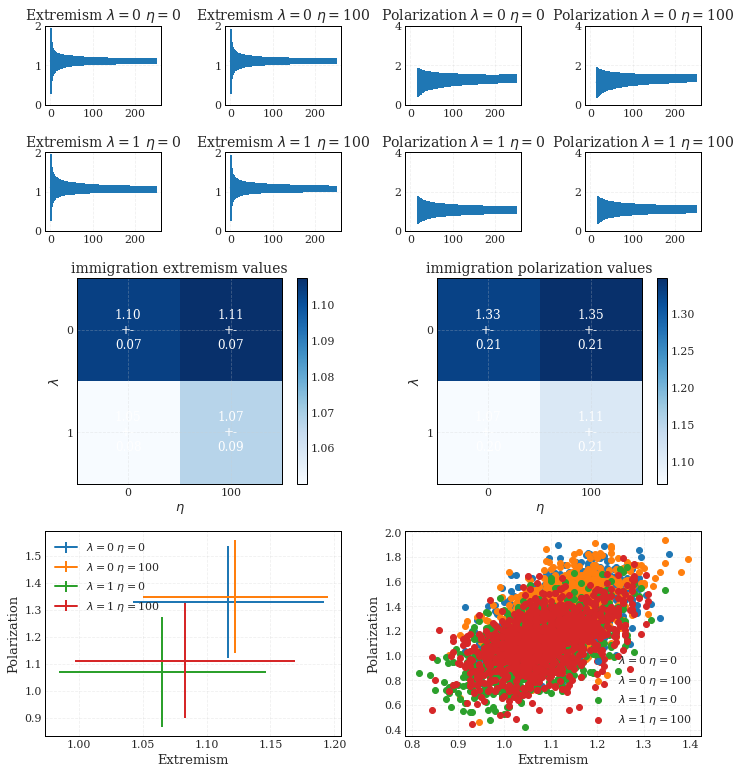

Running simulation for topic climate...


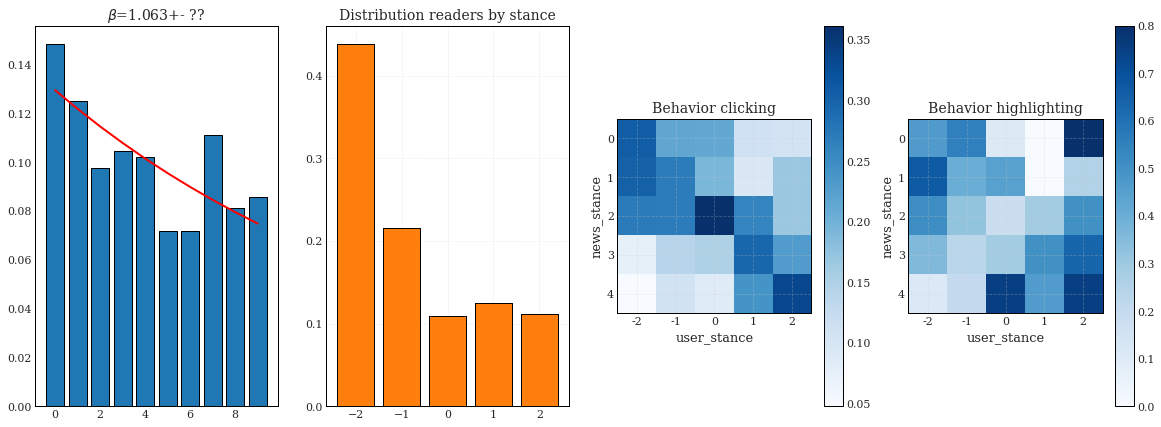

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

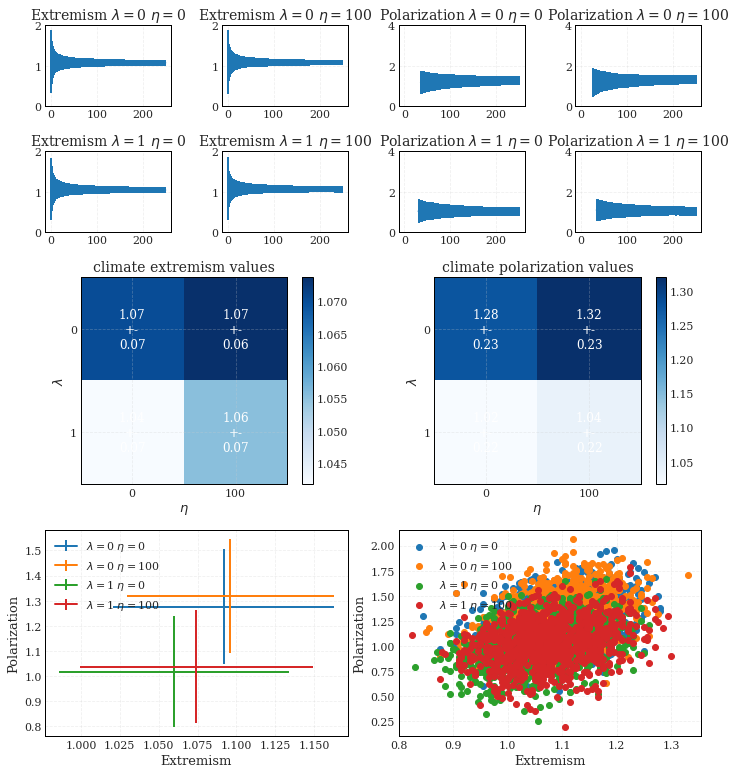

In [6]:
SIMULATION_RESULTS={}

for t_i in range(5):
    if t_i==0:
        t='Overall'
#         t_res=RESULTS
        t_i=None #<--for passing to results_to_simulation_inputs
    else:
        t=N2TOPIC[t_i]
#         t_res=RESULTS[RESULTS['topic']==t_i]
        
        
    beta, d, C, H = results_to_simulation_inputs(RESULTS, 
                                                 lambda z: z<3,
                                                 topic_i=t_i,
                                                 apply_droprule=APPLY_DROPRULE,
                                                 drop_rules=DROP_RULES,
                                                )
    
    print(f"Running simulation for topic {t}...")
    plot_dch(d, C, H)
    plt.show()
    
    C=C.T #<--- because in the run code I index readers by row and news by columns
    H=H.T #<--- because in the run code I index readers by row and news by columns
    
    
    SIMULATION_RESULTS[t]=simulation_grid(beta, d, C, H, 
                                          TURNS, REPETITIONS_PER_EXPERIMENT, METRIC_WINDOW=METRIC_WINDOW)
    
    Fin_extr_avg=SIMULATION_RESULTS[t]['Final_extremism_all_avg']
    Fin_extr_std=SIMULATION_RESULTS[t]['Final_extremism_all_std']
    E_avg, E_std=final_values_to_avgstd(Fin_extr_avg, Fin_extr_std)
    
    Fin_pol_avg=SIMULATION_RESULTS[t]['Final_polarization_avg']
    Fin_pol_std=SIMULATION_RESULTS[t]['Final_polarization_std']
    P_avg, P_std=final_values_to_avgstd(Fin_pol_avg, Fin_pol_std)
    
    plt.figure(figsize=(10,14))
    counter=0
    for lamb, eta2vals in SIMULATION_RESULTS[t]['Extremism_all_avg'].items():
        for eta, vals in eta2vals.items():
            counter+=1
            plot_loc=counter+counter//3*2
            plt.subplot(8,4,plot_loc)
            plt.title(f"Extremism $\lambda=${lamb:d} $\eta=${eta:d}")
            plot_series_avgstd(SIMULATION_RESULTS[t]['Extremism_all_avg'][lamb][eta],
                               SIMULATION_RESULTS[t]['Extremism_all_std'][lamb][eta]
                              )
            plt.ylim(0,2)
            plt.subplot(8,4,plot_loc+2)
            plt.title(f"Polarization $\lambda=${lamb:d} $\eta=${eta:d}")
            plot_series_avgstd(SIMULATION_RESULTS[t]['Polarization_avg'][lamb][eta],
                               SIMULATION_RESULTS[t]['Polarization_std'][lamb][eta]
                              )
            plt.ylim(0,4)
    
    plt.subplot(8,4,(9,14))
    plot_grid_avgstd(E_avg, E_std, Fin_extr_avg, f'{t} extremism')
    plt.subplot(8,4,(11,16))
    plot_grid_avgstd(P_avg, P_std, Fin_pol_avg, f'{t} polarization')
    plt.subplot(8,4,(17,22))
    plot_scatter_extr_vs_pol(SIMULATION_RESULTS[t]['Final_extremism'],
                             SIMULATION_RESULTS[t]['Final_polarization'],
                             only_avgstd=True
                            )
#     plt.title(t)
    plt.xlabel('Extremism')
    plt.ylabel("Polarization")
    plt.subplot(8,4,(19,24))
    plot_scatter_extr_vs_pol(SIMULATION_RESULTS[t]['Final_extremism'],
                             SIMULATION_RESULTS[t]['Final_polarization']
                            )
    plt.xlabel('Extremism')
    plt.ylabel("Polarization")
    plt.tight_layout()
    plt.show()

In [7]:
dir_timers()

  Latest run timer info:

    initialize_altogether__________________________________:____________0.036997_min.
    run____________________________________________________:____________7.358654_min.
    ___clicking_probabilities______________________________:____________1.781012_min.
    ___highlighting_probabilities__________________________:____________0.102066_min.
    metrics________________________________________________:___________24.451373_min.


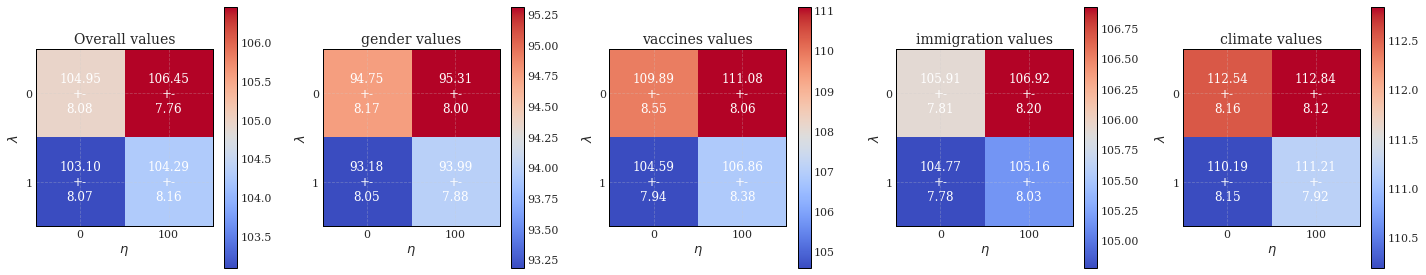

In [8]:
plt.figure(figsize=(20,4))

mpl.rcParams['image.cmap'] = 'coolwarm'

# PT2NH={p:{t:[] for t in range(1,4+1)} for p in [1,2]}
PT2NH_AVG={p:{t:[] for t in range(1,4+1)} for p in [1,2]}
PT2NH_STD={p:{t:[] for t in range(1,4+1)} for p in [1,2]}


for t_i in range(5):
    # Determine topic label
    if t_i == 0:
        t = 'Overall'
        t_i_key = None
    else:
        t = N2TOPIC[t_i]
        t_i_key = t_i

    plt.subplot(1,5,t_i+1)
    # Extract mean and std dictionaries
    m_avg, m_std=final_values_to_avgstd(SIMULATION_RESULTS[t]['N_highlights_avg'], SIMULATION_RESULTS[t]['N_highlights_std'])
    plot_grid_avgstd(m_avg, m_std, SIMULATION_RESULTS[t]['N_highlights_avg'], t)
    
    PT2NH_AVG[1][t_i]=m_avg[1][0]
    PT2NH_AVG[2][t_i]=m_avg[0][1]
    
    PT2NH_STD[1][t_i]=m_std[1][0]
    PT2NH_STD[2][t_i]=m_std[0][1]


plt.tight_layout()
plt.show()


# Save data

In [9]:
import pickle
import os

All data

In [ ]:
with open('../RESULTS_SIMULATION/simulation_corner_data.pkl', 'wb') as f:
    pickle.dump(SIMULATION_RESULTS, f)

Simulation metrics data

In [11]:
TOPIC2N={t:n for n,t in N2TOPIC.items()}

TABLE_RESULTS={}
# for par in [1,2]:
for t in range(1,4+1):
    topic=N2TOPIC[t]
    TABLE_RESULTS['1*'+str(t)]={}
    TABLE_RESULTS['1*'+str(t)]['sim_extremism_avg']=SIMULATION_RESULTS[topic]['Final_extremism_avg'][1][0]
    TABLE_RESULTS['1*'+str(t)]['sim_extremism_std']=SIMULATION_RESULTS[topic]['Final_extremism_std'][1][0]

    TABLE_RESULTS['2*'+str(t)]={}
    TABLE_RESULTS['2*'+str(t)]['sim_extremism_avg']=SIMULATION_RESULTS[topic]['Final_extremism_avg'][0][100] 
    TABLE_RESULTS['2*'+str(t)]['sim_extremism_std']=SIMULATION_RESULTS[topic]['Final_extremism_std'][0][100]        
#     TABLE_RESULTS['1*'+str(t)]={}
    TABLE_RESULTS['1*'+str(t)]['sim_polarization_avg']=SIMULATION_RESULTS[topic]['Final_polarization_avg'][1][0]
    TABLE_RESULTS['1*'+str(t)]['sim_polarization_std']=SIMULATION_RESULTS[topic]['Final_polarization_std'][1][0]
#     TABLE_RESULTS['2*'+str(t)]={}
    TABLE_RESULTS['2*'+str(t)]['sim_polarization_avg']=SIMULATION_RESULTS[topic]['Final_polarization_avg'][0][100]  
    TABLE_RESULTS['2*'+str(t)]['sim_polarization_std']=SIMULATION_RESULTS[topic]['Final_polarization_std'][0][100]  

In [ ]:


# Construct the output path
output_path = f"../RESULTS_SIMULATION/simulation_metrics.pkl"

# Save TABLE_RESULTS as pickle
with open(output_path, "wb") as f:
    pickle.dump(TABLE_RESULTS, f)

print("Saved to:", output_path)

Saved to: simulation_metrics.pkl


click distributions

In [13]:
PARAMPART2CLICKS={pr: {pt: [np.array([0 for _ in range(5)]) for i in range(REPETITIONS_PER_EXPERIMENT)] for pt in [-1,0,1]} for pr in [1,2]} 

for iteration in tqdm(range(REPETITIONS_PER_EXPERIMENT)):
    for param in [1,2]:
        if param==1:
            lam=1
            eta=0
        if param==2:
            lam=0
            eta=100
        for t in range(1,4+1):
            topic=N2TOPIC[t]
            res=SIMULATION_RESULTS[topic]['Final_click_count_partitionwise'][lam][eta]
            for partition in [-1,0,1]:
                to_add_values=res[iteration][partition]
                PARAMPART2CLICKS[param][partition][iteration]+=to_add_values

  0%|          | 0/1000 [00:00<?, ?it/s]

In [14]:
for param in [1,2]:
    for partition in [-1,0,1]:
        PARAMPART2CLICKS[param][partition]=(np.array(PARAMPART2CLICKS[param][partition]).mean(axis=0)*3).astype(int)

In [ ]:
output_path = f"../RESULTS_SIMULATION/simulation_clicks.pkl"

# Save the object
with open(output_path, "wb") as f:
    pickle.dump(PARAMPART2CLICKS, f)

# Plots

In [16]:
def plot_scatter_extr_vs_pol(E, P, color='k', label='', only_avgstd=False):
    color_iter=-1
    colors=['coral','red','c','b',]
    for lamb, eta2values in E.items():
        for eta, extremism_values in eta2values.items():
            color_iter+=1
            color=colors[color_iter]
            if not only_avgstd:
                plt.scatter(extremism_values, P[lamb][eta], label=f'$\lambda=${1-lamb:d} $\eta=${eta:d}', alpha=0.1,
                            color=color,
                           )
            else:
                if eta==0:
                    linestyle=':'
                    print(linestyle)
                else:
                    linestyle='-'
                    print(linestyle)
                E_avg=np.mean(E[lamb][eta])
                E_std=np.std(E[lamb][eta])
                P_avg=np.mean(P[lamb][eta])
                P_std=np.std(P[lamb][eta])
                plt.errorbar(E_avg, P_avg, xerr=E_std, yerr=P_std, label=f'$\lambda=${1-lamb:d} $\eta=${eta:d}', 
                             color=color, linestyle=linestyle,
                             linewidth=2, capsize=0)
    plt.legend()

In [17]:
def plot_scatter_extr_vs_pol(E, P, color='k', label='', only_avgstd=False):
    color_iter = -1
    colors = ['red', 'red', 'b', 'b']
    
    for lamb, eta2values in E.items():
        for eta, extremism_values in eta2values.items():
            color_iter += 1
            color = colors[color_iter]
            
            if not only_avgstd:
                plt.scatter(
                    extremism_values, P[lamb][eta],
                    label=f'$\lambda=${1-lamb:d} $\eta=${eta:d}',
                    alpha=0.1,
                    color=color,
                )
            else:
                E_avg = np.mean(E[lamb][eta])
                E_std = np.std(E[lamb][eta])
                P_avg = np.mean(P[lamb][eta])
                P_std = np.std(P[lamb][eta])

                # Plot error bars and modify their style
                (_, caps, bars) = plt.errorbar(
                    E_avg, P_avg,
                    xerr=E_std, yerr=P_std,
                    label=f'$\lambda=${1-lamb:d} $\eta=${eta:d}',
                    color=color,
                    linewidth=2,
                    capsize=0,
                    markersize=0,
                    fmt='o'   # show only markers, not connecting line
                )

                # Make the actual error bar arms dotted
                for bar in bars:
                    if eta==0:
                        bar.set_linestyle(':')

    plt.legend()

In [18]:
import matplotlib.patches as mpatches


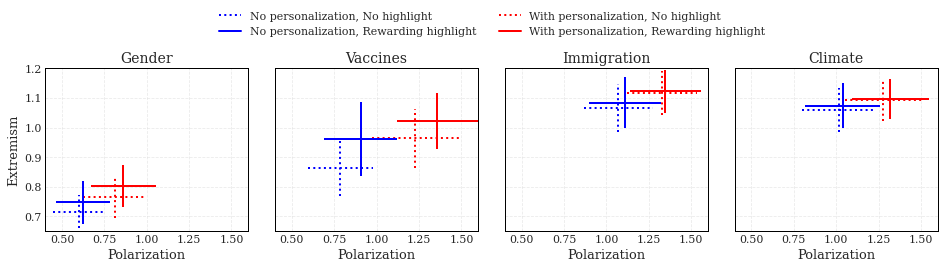

In [19]:
plt.figure(figsize=(16,3))
for t_i in range(1,4+1):
    t=N2TOPIC[t_i]
    plt.subplot(1,4,t_i)
    plot_scatter_extr_vs_pol(SIMULATION_RESULTS[t]['Final_polarization'],
                             SIMULATION_RESULTS[t]['Final_extremism'],
                         
                         only_avgstd=True
                        )
    plt.title(t.capitalize())
    plt.grid(alpha=0.2)
    plt.xlabel('Polarization')
    if t_i in [1]:
        plt.ylabel("Extremism")
    plt.legend(loc='lower right').remove()
        
    plt.ylim(0.65,1.2)
    plt.xlim(0.4, 1.6)
    
    if t_i!=1:
        plt.tick_params(axis='y', labelleft=False)
    
    plt.grid(alpha=0.4)
    
plt.subplot(1,4,1)

from matplotlib.lines import Line2D

legend_patches = [
    Line2D([0], [0], color="blue", linestyle=":",  label="No personalization, No highlight"),
    Line2D([0], [0], color="blue", linestyle="-",  label="No personalization, Rewarding highlight"),
    Line2D([0], [0], color="red",  linestyle=":",  label="With personalization, No highlight"),
    Line2D([0], [0], color="red",  linestyle="-",  label="With personalization, Rewarding highlight"),
]

# # Manual legend above plots
plt.legend(
    handles=legend_patches,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(2.2, 1.41),
    frameon=False
)
plt.subplots_adjust(wspace=0.13) 
# plt.tight_layout()
# plt.savefig("figures/topicwise_lift.pdf", bbox_inches='tight')
plt.savefig('topicwise_simulation_corners.pdf', bbox_inches='tight')
plt.savefig('topicwise_simulation_corners.png', bbox_inches='tight')